# 03. Extension de regresion: estimacion de `ARR_DELAY`

Desarrollamos la parte de regresión lineal del proyecto como una extension coherente del problema principal de clasificacion. En lugar de predecir si un vuelo llega con al menos 15 minutos de retraso, aqui intentamos estimar **cuantos minutos** se retrasa la llegada.

Objetivos:
- construir una linea base minima para la regresion,
- ajustar un modelo lineal interpretable en estilo de clase con `statsmodels`,
- diagnosticar residuos, outliers influyentes y colinealidad,
- comparar ese modelo con un enfoque no lineal mas flexible,
- cerrar con una comparacion clara sobre el holdout temporal de 2024.


## Marco metodologico

Seguimos la metodologia temporal fijada:
- `train_2023`: meses 1 a 9 de 2023 para entrenamiento,







































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































- `valid_2023`: meses 10 a 12 de 2023 para comparacion y seleccion de modelos,
- `test_2024`: todo 2024 como holdout final.

Esta separacion temporal es mas realista que un split aleatorio porque replica mejor el problema operativo: entrenamos con vuelos del pasado y evaluamos sobre vuelos futuros. Ademas, evita inflar artificialmente el rendimiento al mezclar observaciones de periodos muy cercanos.

Reglas:
- la variable objetivo es `ARR_DELAY`,
- `delay_15` se excluye de los predictores porque deriva directamente del target y produciria leakage,
- solo se usan variables disponibles **antes del despegue** o proxies historicas construidas sin usar el target,
- no se modifica ningun artefacto dentro de `data/`.


In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from IPython.display import Markdown, display
from scipy import stats
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from statsmodels.stats.outliers_influence import variance_inflation_factor

warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.labelsize"] = 11
plt.rcParams["xtick.labelsize"] = 9
plt.rcParams["ytick.labelsize"] = 9
plt.rcParams["figure.max_open_warning"] = 0

pd.set_option("display.max_columns", 80)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")


In [2]:
ROOT = Path.cwd()

CANDIDATE_DATA_DIRS = [
    ROOT / "data" / "final",
    ROOT / "data" / "data" / "final",
    ROOT.parent / "data" / "final",
    ROOT.parent / "data" / "data" / "final",
]


def resolve_data_dir(candidate_dirs):
    required_names = {"train_2023.parquet", "valid_2023.parquet", "test_2024.parquet"}
    for candidate in candidate_dirs:
        if candidate.exists() and required_names.issubset({path.name for path in candidate.iterdir() if path.is_file()}):
            return candidate

    checked = "\n".join(str(path) for path in candidate_dirs)
    raise FileNotFoundError(
        "No se encontro la carpeta final con los parquet esperados. Se revisaron estas rutas:\n"
        f"{checked}"
    )


DATA_DIR = resolve_data_dir(CANDIDATE_DATA_DIRS)

TRAIN_PATH = DATA_DIR / "train_2023.parquet"
VALID_PATH = DATA_DIR / "valid_2023.parquet"
TEST_PATH = DATA_DIR / "test_2024.parquet"

TARGET_COL = "ARR_DELAY"
LEAKAGE_COL = "delay_15"
RANDOM_STATE = 42

REQUIRED_COLUMNS = [
    "YEAR",
    "MONTH",
    "DAY_OF_MONTH",
    "DAY_OF_WEEK",
    "OP_UNIQUE_CARRIER",
    "ORIGIN",
    "ORIGIN_STATE_ABR",
    "DEST",
    "DEST_STATE_ABR",
    "CRS_DEP_TIME",
    "DEP_TIME_BLK",
    "ARR_DELAY",
    "CANCELLED",
    "DIVERTED",
    "DISTANCE",
    "DISTANCE_GROUP",
    "delay_15",
]

TOP_CATEGORY_LIMITS = {"ORIGIN": 25, "DEST": 25, "route": 40}
TEMPORAL_SORT_COLS = ["MONTH", "DAY_OF_MONTH", "CRS_DEP_TIME"]
OLS_MAX_ROWS = 200_000
OLS_PREDICT_CHUNK_SIZE = 200_000
OLS_DIAGNOSTIC_MAX_ROWS = 20_000
RF_MAX_ROWS = 80_000
RF_PREDICT_CHUNK_SIZE = 200_000

model_results = []
model_predictions = {}


## 1. Carga de datos

Cargamos los datos temporales del proyecto.


In [3]:
print(f"Ruta de datos detectada: {DATA_DIR}")

assert TRAIN_PATH.exists() and VALID_PATH.exists() and TEST_PATH.exists(), "No se localizaron los tres parquet requeridos."

train_df = pd.read_parquet(TRAIN_PATH)
valid_df = pd.read_parquet(VALID_PATH)
test_df = pd.read_parquet(TEST_PATH)

for split_name, df in {"train_2023": train_df, "valid_2023": valid_df, "test_2024": test_df}.items():
    missing_cols = [col for col in REQUIRED_COLUMNS if col not in df.columns]
    if missing_cols:
        raise ValueError(f"{split_name} no contiene las columnas esperadas: {missing_cols}")

assert set(train_df.columns) == set(valid_df.columns) == set(test_df.columns), "Los splits deben compartir el mismo esquema."
assert train_df["MONTH"].between(1, 9).all(), "train_2023 debe contener meses 1 a 9."
assert valid_df["MONTH"].between(10, 12).all(), "valid_2023 debe contener meses 10 a 12."
assert (test_df["YEAR"] == 2024).all(), "test_2024 debe pertenecer a 2024."


Ruta de datos detectada: c:\Users\raffa\OneDrive\Documents\2026\Machine Learning\TrabajoFinalMachine\PrediccionRetrasosVuelos-ML\data\data\final


In [4]:
dataset_overview = pd.DataFrame(
    [
        {
            "dataset": "train_2023",
            "shape": train_df.shape,
            "year_range": sorted(train_df["YEAR"].unique().tolist()),
            "month_range": [int(train_df["MONTH"].min()), int(train_df["MONTH"].max())],
            "arr_delay_mean": train_df[TARGET_COL].mean(),
            "arr_delay_median": train_df[TARGET_COL].median(),
        },
        {
            "dataset": "valid_2023",
            "shape": valid_df.shape,
            "year_range": sorted(valid_df["YEAR"].unique().tolist()),
            "month_range": [int(valid_df["MONTH"].min()), int(valid_df["MONTH"].max())],
            "arr_delay_mean": valid_df[TARGET_COL].mean(),
            "arr_delay_median": valid_df[TARGET_COL].median(),
        },
        {
            "dataset": "test_2024",
            "shape": test_df.shape,
            "year_range": sorted(test_df["YEAR"].unique().tolist()),
            "month_range": [int(test_df["MONTH"].min()), int(test_df["MONTH"].max())],
            "arr_delay_mean": test_df[TARGET_COL].mean(),
            "arr_delay_median": test_df[TARGET_COL].median(),
        },
    ]
)

display(dataset_overview)


,dataset,shape,year_range,month_range,arr_delay_mean,arr_delay_median
0,train_2023,"(5018046, 17)",[2023],"[1, 9]",8.848,-5.000
1,valid_2023,"(1725357, 17)",[2023],"[10, 12]",0.168,-8.000
2,test_2024,"(6965267, 17)",[2024],"[1, 12]",7.098,-6.000


## 2. Selección de variables y construcción de features seguras

Para regresion, el target es `ARR_DELAY`. Eso significa que `delay_15` debe salir de la matriz de entrada porque es una transformacion directa de la variable objetivo.

Ademas, nos limitamos a variables disponibles antes del despegue:
- calendario (`MONTH`, `DAY_OF_MONTH`, `DAY_OF_WEEK`),
- planificacion (`CRS_DEP_TIME`, `DEP_TIME_BLK`),
- operacion prevista (`OP_UNIQUE_CARRIER`, `ORIGIN`, `DEST`, estados origen/destino),
- distancia y variables derivadas puramente historicas,
- proxies de frecuencia o congestion calculadas **solo con train_2023** y sin usar `ARR_DELAY`.


In [5]:
def make_time_features(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()

    dep_time = (
        pd.to_numeric(out["CRS_DEP_TIME"], errors="coerce")
        .fillna(0)
        .astype(int)
        .astype(str)
        .str.zfill(4)
    )
    out["crs_dep_hour"] = dep_time.str[:2].astype(int)
    out["crs_dep_minute"] = dep_time.str[2:].astype(int)

    out["dep_period"] = pd.cut(
        out["crs_dep_hour"],
        bins=[-1, 5, 11, 17, 23],
        labels=["madrugada", "manana", "tarde", "noche"],
    ).astype(str)

    out["route"] = out["ORIGIN"].astype(str) + "_" + out["DEST"].astype(str)
    out["is_weekend"] = out["DAY_OF_WEEK"].isin([6, 7]).astype(int)
    return out


def fit_frequency_maps(df: pd.DataFrame) -> dict:
    n_rows = len(df)
    return {
        "carrier_frequency": df["OP_UNIQUE_CARRIER"].value_counts(normalize=True),
        "origin_frequency": df["ORIGIN"].value_counts(normalize=True),
        "dest_frequency": df["DEST"].value_counts(normalize=True),
        "route_frequency": df["route"].value_counts(normalize=True),
        "origin_hour_frequency": (
            df.groupby(["ORIGIN", "crs_dep_hour"]).size().div(n_rows).rename("origin_hour_frequency")
        ),
    }


def apply_frequency_maps(df: pd.DataFrame, frequency_maps: dict) -> pd.DataFrame:
    out = df.copy()
    out["carrier_frequency"] = out["OP_UNIQUE_CARRIER"].map(frequency_maps["carrier_frequency"]).fillna(0.0)
    out["origin_frequency"] = out["ORIGIN"].map(frequency_maps["origin_frequency"]).fillna(0.0)
    out["dest_frequency"] = out["DEST"].map(frequency_maps["dest_frequency"]).fillna(0.0)
    out["route_frequency"] = out["route"].map(frequency_maps["route_frequency"]).fillna(0.0)
    out["origin_hour_frequency"] = (
        pd.MultiIndex.from_frame(out[["ORIGIN", "crs_dep_hour"]])
        .map(frequency_maps["origin_hour_frequency"])
        .fillna(0.0)
        .to_numpy()
    )
    return out


def fit_top_categories(df: pd.DataFrame, limits: dict) -> dict:
    top_levels = {}
    for col, top_n in limits.items():
        top_levels[col] = df[col].value_counts().head(top_n).index.tolist()
    return top_levels


def apply_top_categories(df: pd.DataFrame, top_levels: dict) -> pd.DataFrame:
    out = df.copy()
    for raw_col, top_values in top_levels.items():
        grouped_col = f"{raw_col.upper()}_GROUPED"
        out[grouped_col] = np.where(out[raw_col].isin(top_values), out[raw_col], "OTHER")
    return out


def temporal_sort(df: pd.DataFrame) -> pd.DataFrame:
    available_sort_cols = [col for col in TEMPORAL_SORT_COLS if col in df.columns]
    return df.sort_values(available_sort_cols).reset_index(drop=True)


In [6]:
train_feat = make_time_features(train_df)
valid_feat = make_time_features(valid_df)
test_feat = make_time_features(test_df)

frequency_maps = fit_frequency_maps(train_feat)

train_feat = apply_frequency_maps(train_feat, frequency_maps)
valid_feat = apply_frequency_maps(valid_feat, frequency_maps)
test_feat = apply_frequency_maps(test_feat, frequency_maps)

top_levels = fit_top_categories(train_feat, TOP_CATEGORY_LIMITS)

train_feat = apply_top_categories(train_feat, top_levels)
valid_feat = apply_top_categories(valid_feat, top_levels)
test_feat = apply_top_categories(test_feat, top_levels)

excluded_feature_reasons = {
    TARGET_COL: "Es la variable objetivo de la regresion.",
    LEAKAGE_COL: "Se deriva directamente de ARR_DELAY y produciria leakage.",
    "YEAR": "Identifica el periodo, pero no aporta senal util dentro de cada split y puede capturar cambio temporal bruto.",
    "CANCELLED": "Tras el preprocesado deberia quedar constante y no describe un vuelo operado.",
    "DIVERTED": "Tras el preprocesado deberia quedar constante y no es una variable previa al aterrizaje final.",
}

candidate_features = [
    "MONTH",
    "DAY_OF_MONTH",
    "DAY_OF_WEEK",
    "CRS_DEP_TIME",
    "DEP_TIME_BLK",
    "crs_dep_hour",
    "crs_dep_minute",
    "dep_period",
    "is_weekend",
    "OP_UNIQUE_CARRIER",
    "ORIGIN",
    "DEST",
    "ORIGIN_STATE_ABR",
    "DEST_STATE_ABR",
    "route",
    "DISTANCE",
    "DISTANCE_GROUP",
    "carrier_frequency",
    "origin_frequency",
    "dest_frequency",
    "route_frequency",
    "origin_hour_frequency",
    "ORIGIN_GROUPED",
    "DEST_GROUPED",
    "ROUTE_GROUPED",
]

feature_audit = pd.DataFrame(
    {
        "feature": list(excluded_feature_reasons.keys()) + candidate_features,
        "status": ["excluded"] * len(excluded_feature_reasons) + ["allowed"] * len(candidate_features),
        "reason": list(excluded_feature_reasons.values()) + ["Disponible antes del despegue o derivada de forma segura."] * len(candidate_features),
    }
)

display(feature_audit)


,feature,status,reason
0,ARR_DELAY,excluded,Es la variable objetivo de la regresion.
1,delay_15,excluded,Se deriva directamente de ARR_DELAY y producir...
2,YEAR,excluded,"Identifica el periodo, pero no aporta senal ut..."
3,CANCELLED,excluded,Tras el preprocesado deberia quedar constante ...
4,DIVERTED,excluded,Tras el preprocesado deberia quedar constante ...
5,MONTH,allowed,Disponible antes del despegue o derivada de fo...
6,DAY_OF_MONTH,allowed,Disponible antes del despegue o derivada de fo...
7,DAY_OF_WEEK,allowed,Disponible antes del despegue o derivada de fo...
8,CRS_DEP_TIME,allowed,Disponible antes del despegue o derivada de fo...
9,DEP_TIME_BLK,allowed,Disponible antes del despegue o derivada de fo...


## 3. Definicion del problema de regresion

La variable objetivo es `ARR_DELAY`, es decir, el retraso de llegada en minutos. Esta extension complementa la clasificacion porque no solo distingue entre retraso relevante o no, sino que intenta estimar **la magnitud** del desvio operativo.

Un detalle importante es que `ARR_DELAY` suele incluir:
- valores negativos (vuelos que llegan antes de lo previsto),
- una masa grande cerca de 0,
- una cola derecha larga con retrasos severos.

Por esa razon:
- una transformacion logaritmica directa no es tan comoda, porque el target puede ser negativo,
- no eliminamos outliers de entrada: primero los describimos y luego analizamos su efecto mediante MAE, RMSE y diagnostico de residuos.


In [7]:
print("Info de train_2023")
train_feat.info()

display(train_feat.describe(include="all").transpose().head(25))

null_pct = (
    train_feat.isna()
    .mean()
    .mul(100)
    .rename("null_pct")
    .sort_values(ascending=False)
    .reset_index()
    .rename(columns={"index": "feature"})
)

display(null_pct.head(20))

target_overview = pd.DataFrame(
    {
        "metric": [
            "mean",
            "median",
            "std",
            "min",
            "p01",
            "p05",
            "p95",
            "p99",
            "max",
            "share_negative",
            "skewness",
        ],
        "value": [
            train_feat[TARGET_COL].mean(),
            train_feat[TARGET_COL].median(),
            train_feat[TARGET_COL].std(),
            train_feat[TARGET_COL].min(),
            train_feat[TARGET_COL].quantile(0.01),
            train_feat[TARGET_COL].quantile(0.05),
            train_feat[TARGET_COL].quantile(0.95),
            train_feat[TARGET_COL].quantile(0.99),
            train_feat[TARGET_COL].max(),
            (train_feat[TARGET_COL] < 0).mean(),
            stats.skew(train_feat[TARGET_COL], bias=False, nan_policy="omit"),
        ],
    }
)

display(target_overview)


Info de train_2023
<class 'pandas.DataFrame'>
RangeIndex: 5018046 entries, 0 to 5018045
Data columns (total 30 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   YEAR                   int16  
 1   MONTH                  int8   
 2   DAY_OF_MONTH           int8   
 3   DAY_OF_WEEK            int8   
 4   OP_UNIQUE_CARRIER      str    
 5   ORIGIN                 str    
 6   ORIGIN_STATE_ABR       str    
 7   DEST                   str    
 8   DEST_STATE_ABR         str    
 9   CRS_DEP_TIME           Int32  
 10  DEP_TIME_BLK           str    
 11  ARR_DELAY              float32
 12  CANCELLED              int8   
 13  DIVERTED               int8   
 14  DISTANCE               float32
 15  DISTANCE_GROUP         int8   
 16  delay_15               int8   
 17  crs_dep_hour           int64  
 18  crs_dep_minute         int64  
 19  dep_period             str    
 20  route                  str    
 21  is_weekend             int64  
 22  carrier_fr

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
YEAR,"5,018,046.000",NaN,NaN,NaN,"2,023.000",0.000,"2,023.000","2,023.000","2,023.000","2,023.000","2,023.000"
MONTH,"5,018,046.000",NaN,NaN,NaN,5.094,2.559,1.000,3.000,5.000,7.000,9.000
DAY_OF_MONTH,"5,018,046.000",NaN,NaN,NaN,15.745,8.748,1.000,8.000,16.000,23.000,31.000
DAY_OF_WEEK,"5,018,046.000",NaN,NaN,NaN,3.972,1.997,1.000,2.000,4.000,6.000,7.000
OP_UNIQUE_CARRIER,5018046,15,WN,1044077,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ORIGIN,5018046,349,ATL,248383,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ORIGIN_STATE_ABR,5018046,52,CA,543481,NaN,NaN,NaN,NaN,NaN,NaN,NaN
DEST,5018046,349,ATL,248275,NaN,NaN,NaN,NaN,NaN,NaN,NaN
DEST_STATE_ABR,5018046,52,CA,544026,NaN,NaN,NaN,NaN,NaN,NaN,NaN
CRS_DEP_TIME,"5,018,046.000",<NA>,<NA>,<NA>,"1,331.848",497.202,1.000,909.000,"1,321.000","1,741.000","2,359.000"


,feature,null_pct
0,YEAR,0.000
1,MONTH,0.000
2,DAY_OF_MONTH,0.000
3,DAY_OF_WEEK,0.000
4,OP_UNIQUE_CARRIER,0.000
5,ORIGIN,0.000
6,ORIGIN_STATE_ABR,0.000
7,DEST,0.000
8,DEST_STATE_ABR,0.000
9,CRS_DEP_TIME,0.000


,metric,value
0,mean,8.848
1,median,-5.000
2,std,60.149
3,min,-119.000
4,p01,-36.000
5,p05,-26.000
6,p95,86.000
7,p99,218.000
8,max,"4,405.000"
9,share_negative,0.593


## 4. Análisis exploratorio

Documentamos patrones que ayuden a entender si una regresion lineal puede ser suficiente o si conviene comparar con un modelo mas flexible.


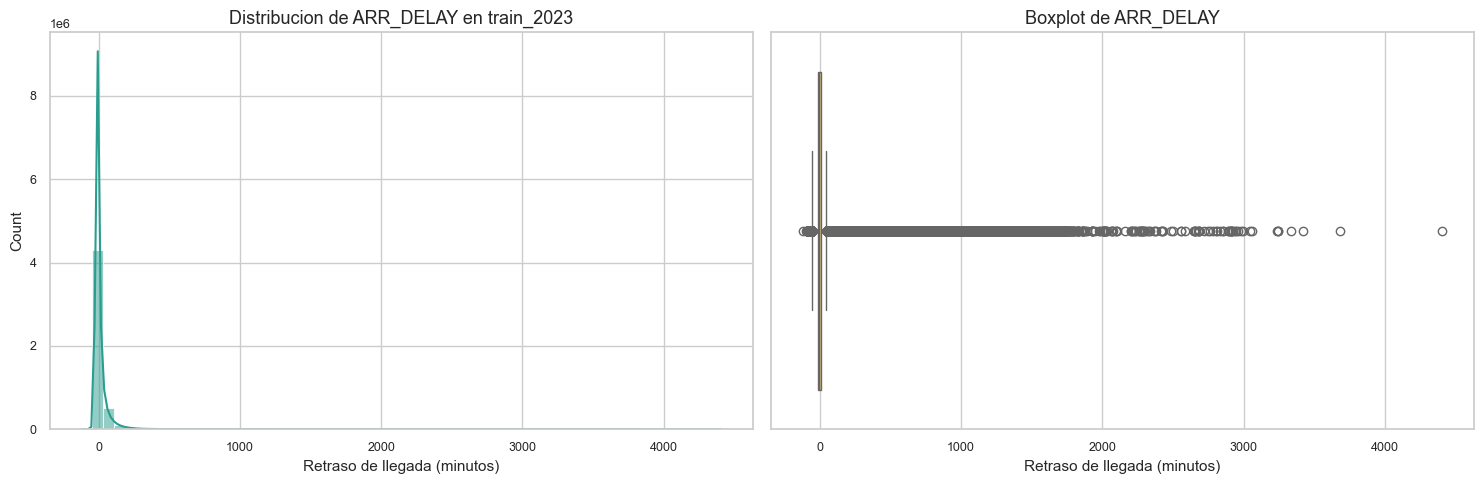

,percentile,ARR_DELAY
0,p50,-5.000
1,p75,11.000
2,p90,46.000
3,p95,86.000
4,p99,218.000


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.histplot(train_feat[TARGET_COL], bins=60, kde=True, ax=axes[0], color="#2a9d8f")
axes[0].set_title("Distribucion de ARR_DELAY en train_2023")
axes[0].set_xlabel("Retraso de llegada (minutos)")

sns.boxplot(x=train_feat[TARGET_COL], ax=axes[1], color="#e9c46a")
axes[1].set_title("Boxplot de ARR_DELAY")
axes[1].set_xlabel("Retraso de llegada (minutos)")

plt.tight_layout()
plt.show()

tail_comment = pd.DataFrame(
    {
        "percentile": ["p50", "p75", "p90", "p95", "p99"],
        "ARR_DELAY": [
            train_feat[TARGET_COL].quantile(0.50),
            train_feat[TARGET_COL].quantile(0.75),
            train_feat[TARGET_COL].quantile(0.90),
            train_feat[TARGET_COL].quantile(0.95),
            train_feat[TARGET_COL].quantile(0.99),
        ],
    }
)

display(tail_comment)


,dep_period,count,mean,median
2,noche,1163315,17.233,-1.000
3,tarde,1754688,11.952,-3.000
1,manana,1945860,1.781,-8.000
0,madrugada,154183,-0.549,-10.000


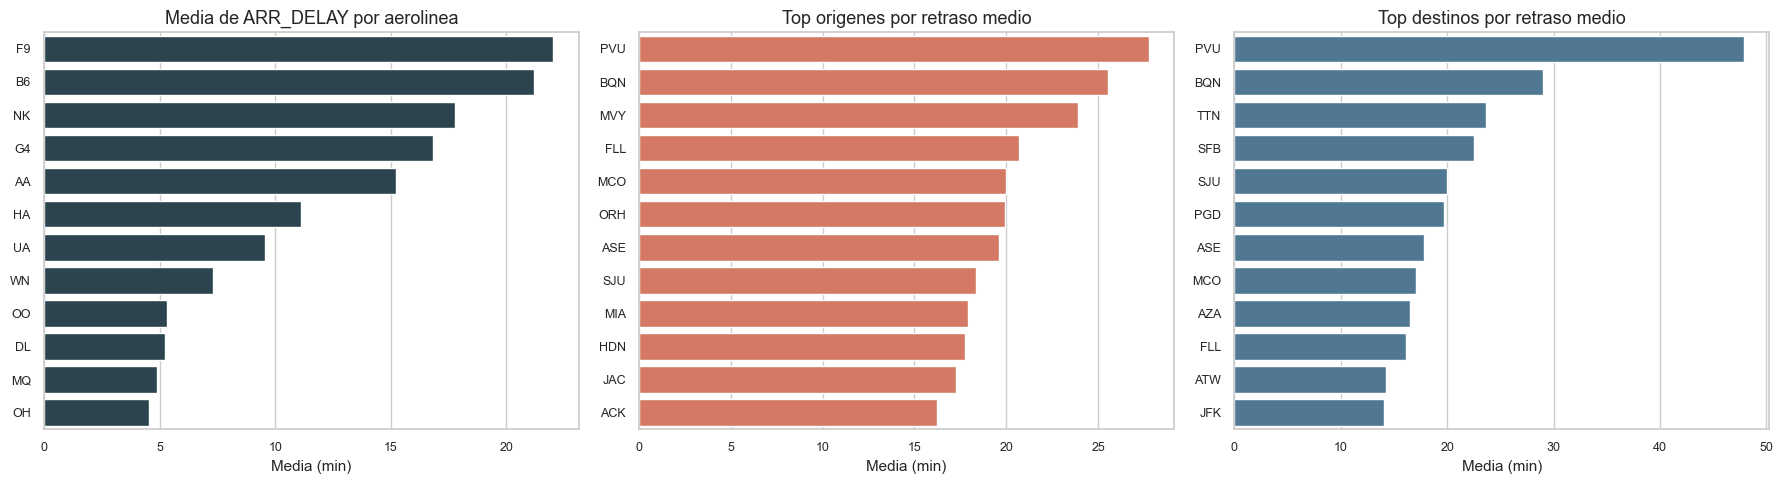

In [9]:
dep_period_delay = (
    train_feat.groupby("dep_period", observed=False)[TARGET_COL]
    .agg(["count", "mean", "median"])
    .reset_index()
    .sort_values("mean", ascending=False)
)
display(dep_period_delay)

carrier_delay = (
    train_feat.groupby("OP_UNIQUE_CARRIER")[TARGET_COL]
    .agg(["count", "mean", "median"])
    .query("count >= 500")
    .sort_values("mean", ascending=False)
    .head(12)
    .reset_index()
)

origin_delay = (
    train_feat.groupby("ORIGIN")[TARGET_COL]
    .agg(["count", "mean", "median"])
    .query("count >= 1000")
    .sort_values("mean", ascending=False)
    .head(12)
    .reset_index()
)

dest_delay = (
    train_feat.groupby("DEST")[TARGET_COL]
    .agg(["count", "mean", "median"])
    .query("count >= 1000")
    .sort_values("mean", ascending=False)
    .head(12)
    .reset_index()
)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.barplot(data=carrier_delay, x="mean", y="OP_UNIQUE_CARRIER", ax=axes[0], color="#264653")
axes[0].set_title("Media de ARR_DELAY por aerolinea")
axes[0].set_xlabel("Media (min)")
axes[0].set_ylabel("")

sns.barplot(data=origin_delay, x="mean", y="ORIGIN", ax=axes[1], color="#e76f51")
axes[1].set_title("Top origenes por retraso medio")
axes[1].set_xlabel("Media (min)")
axes[1].set_ylabel("")

sns.barplot(data=dest_delay, x="mean", y="DEST", ax=axes[2], color="#457b9d")
axes[2].set_title("Top destinos por retraso medio")
axes[2].set_xlabel("Media (min)")
axes[2].set_ylabel("")

plt.tight_layout()
plt.show()


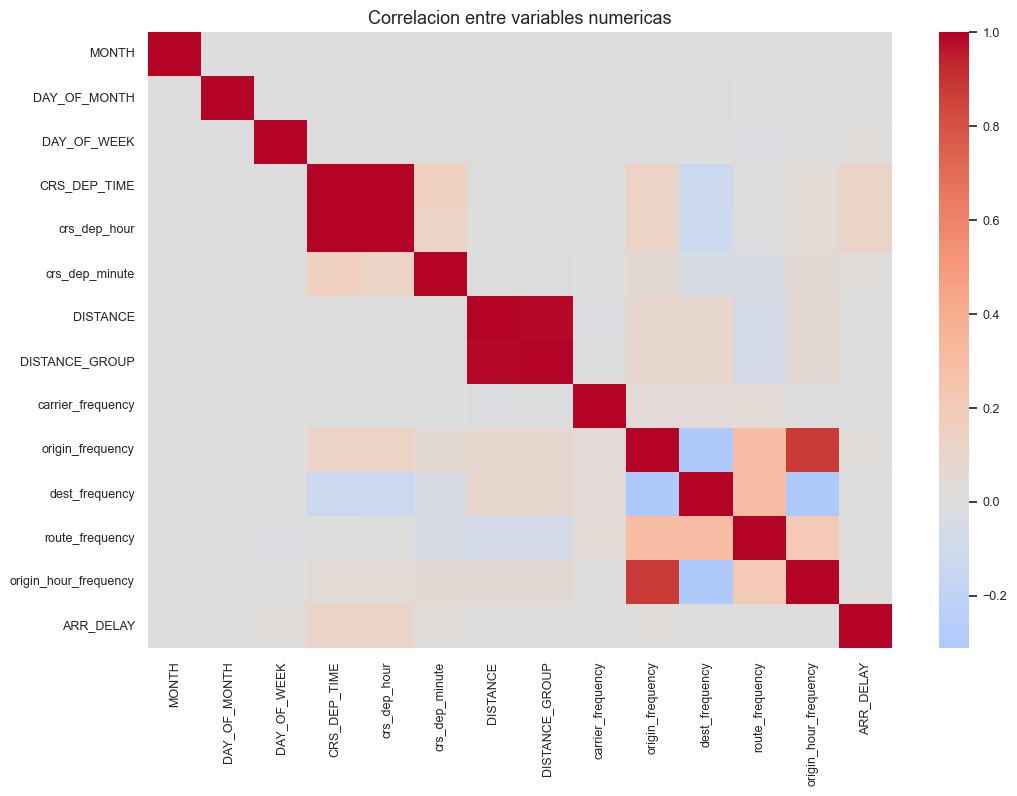

,ARR_DELAY
ARR_DELAY,1.000
CRS_DEP_TIME,0.110
crs_dep_hour,0.110
origin_frequency,0.021
DAY_OF_WEEK,0.020
crs_dep_minute,0.020
MONTH,0.016
DISTANCE_GROUP,0.016
DISTANCE,0.015
route_frequency,0.015


In [10]:
numeric_eda_cols = [
    "MONTH",
    "DAY_OF_MONTH",
    "DAY_OF_WEEK",
    "CRS_DEP_TIME",
    "crs_dep_hour",
    "crs_dep_minute",
    "DISTANCE",
    "DISTANCE_GROUP",
    "carrier_frequency",
    "origin_frequency",
    "dest_frequency",
    "route_frequency",
    "origin_hour_frequency",
    TARGET_COL,
]

numeric_eda_cols = [col for col in numeric_eda_cols if col in train_feat.columns]

corr_matrix = train_feat[numeric_eda_cols].corr(numeric_only=True)

plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, cmap="coolwarm", center=0, annot=False)
plt.title("Correlacion entre variables numericas")
plt.show()

display(corr_matrix[[TARGET_COL]].sort_values(TARGET_COL, ascending=False))


## 5. Preprocesado

El preprocesado se ajusta solo con `train_2023` y luego se aplica a `valid_2023` y `test_2024`.

Como el dataset completo tiene millones de vuelos, los modelos que consumen más memoria (`statsmodels` OLS y el ajuste de `RandomForestRegressor`) se entrenan sobre una **submuestra reproducible y estratificada por mes** de `train_2023`. 

Decisiones de diseño:
- **OLS con statsmodels**: mantenemos las variables en unidades originales para conservar interpretabilidad. Imputamos nulos y codificamos categoricas con dummies, pero no escalamos.
- **Random Forest**: imputamos y codificamos categoricas; no escalamos porque los arboles toman decisiones por umbrales y no dependen de la escala de las features.

Las proxies de frecuencia (`carrier_frequency`, `route_frequency`, etc.) se calculan unicamente a partir de `train_2023`, de modo que representan conocimiento historico disponible sin usar el target.


In [11]:

def keep_available(df: pd.DataFrame, columns: list[str]) -> list[str]:
    return [col for col in columns if col in df.columns]


def make_model_sample(df: pd.DataFrame, max_rows: int, group_col: str = "MONTH", random_state: int = RANDOM_STATE) -> pd.DataFrame:
    if len(df) <= max_rows:
        return temporal_sort(df.copy())

    sampled_parts = []
    for _, group in df.groupby(group_col, observed=False):
        frac = len(group) / len(df)
        n_group = max(1, int(round(max_rows * frac)))
        n_group = min(n_group, len(group))
        sampled_parts.append(group.sample(n=n_group, random_state=random_state))

    sampled = pd.concat(sampled_parts, axis=0)
    if len(sampled) > max_rows:
        sampled = sampled.sample(n=max_rows, random_state=random_state)

    return temporal_sort(sampled)


# Para el OLS priorizamos una unica senal temporal principal y facil de defender.
# Mantenemos crs_dep_hour y dejamos fuera otras representaciones casi equivalentes
# (crs_dep_minute, DEP_TIME_BLK y dep_period) para reducir redundancia y VIF.
ols_numeric_features = keep_available(
    train_feat,
    [
        "MONTH",
        "DAY_OF_MONTH",
        "DAY_OF_WEEK",
        "crs_dep_hour",
        "DISTANCE",
        "DISTANCE_GROUP",
        "is_weekend",
        "carrier_frequency",
        "origin_frequency",
        "dest_frequency",
        "route_frequency",
        "origin_hour_frequency",
    ],
)

ols_categorical_features = keep_available(
    train_feat,
    [
        "OP_UNIQUE_CARRIER",
        "ORIGIN_STATE_ABR",
        "DEST_STATE_ABR",
    ],
)

# En Random Forest podemos permitir una representacion temporal algo mas rica,
# porque el modelo no sufre del mismo modo por la colinealidad entre predictores.
tree_numeric_features = keep_available(
    train_feat,
    [
        "MONTH",
        "DAY_OF_MONTH",
        "DAY_OF_WEEK",
        "crs_dep_hour",
        "crs_dep_minute",
        "DISTANCE",
        "DISTANCE_GROUP",
        "is_weekend",
        "carrier_frequency",
        "origin_frequency",
        "dest_frequency",
        "route_frequency",
        "origin_hour_frequency",
    ],
)

tree_categorical_features = keep_available(
    train_feat,
    [
        "OP_UNIQUE_CARRIER",
        "ORIGIN_GROUPED",
        "DEST_GROUPED",
        "ROUTE_GROUPED",
        "ORIGIN_STATE_ABR",
        "DEST_STATE_ABR",
        "DEP_TIME_BLK",
        "dep_period",
    ],
)


def regression_metrics(y_true, y_pred, model_name: str, split_name: str) -> dict:
    mse = mean_squared_error(y_true, y_pred)
    return {
        "model": model_name,
        "split": split_name,
        "MAE": mean_absolute_error(y_true, y_pred),
        "MSE": mse,
        "RMSE": np.sqrt(mse),
        "R2": r2_score(y_true, y_pred),
    }


def register_results(model_name: str, split_name: str, y_true: pd.Series, y_pred: np.ndarray) -> None:
    model_results[:] = [
        row for row in model_results
        if not (row["model"] == model_name and row["split"] == split_name)
    ]
    model_results.append(regression_metrics(y_true, y_pred, model_name, split_name))
    model_predictions.setdefault(model_name, {})[split_name] = {
        "y_true": np.asarray(y_true),
        "y_pred": np.asarray(y_pred),
    }


def build_ols_design(train_frame: pd.DataFrame, numeric_cols: list[str], categorical_cols: list[str]):
    train_num = train_frame[numeric_cols].copy()
    medians = train_num.median()
    train_num = train_num.fillna(medians).astype("float32")

    train_cat = train_frame[categorical_cols].copy().fillna("Missing")
    train_dummies = pd.get_dummies(train_cat, drop_first=True, dtype="uint8")
    train_design = pd.concat([train_num, train_dummies], axis=1).astype("float32")
    train_columns = train_design.columns.tolist()
    return train_design, medians, train_columns


def transform_ols_design(frame: pd.DataFrame, numeric_cols: list[str], categorical_cols: list[str], medians: pd.Series, train_columns: list[str]):
    other_num = frame[numeric_cols].copy().fillna(medians).astype("float32")
    other_cat = frame[categorical_cols].copy().fillna("Missing")
    other_dummies = pd.get_dummies(other_cat, drop_first=True, dtype="uint8")
    design = pd.concat([other_num, other_dummies], axis=1)
    design = design.reindex(columns=train_columns, fill_value=0)
    return design.astype("float32")


def predict_ols_in_chunks(model, frame: pd.DataFrame, numeric_cols: list[str], categorical_cols: list[str], medians: pd.Series, train_columns: list[str], selected_cols=None, chunk_size=None):
    if chunk_size is None:
        chunk_size = globals().get("OLS_PREDICT_CHUNK_SIZE", 200_000)

    preds = []
    for start in range(0, len(frame), chunk_size):
        stop = min(start + chunk_size, len(frame))
        chunk = frame.iloc[start:stop].copy()
        chunk_design = transform_ols_design(chunk, numeric_cols, categorical_cols, medians, train_columns)
        if selected_cols is not None:
            chunk_design = chunk_design[selected_cols]
        chunk_pred = model.predict(sm.add_constant(chunk_design, has_constant="add"))
        preds.append(np.asarray(chunk_pred, dtype="float32"))
    return np.concatenate(preds)


def predict_sklearn_in_chunks(model, frame: pd.DataFrame, chunk_size: int | None = None) -> np.ndarray:
    if chunk_size is None:
        chunk_size = globals().get("RF_PREDICT_CHUNK_SIZE", 200_000)

    preds = []
    for start in range(0, len(frame), chunk_size):
        stop = min(start + chunk_size, len(frame))
        chunk = frame.iloc[start:stop].copy()
        chunk_pred = model.predict(chunk)
        preds.append(np.asarray(chunk_pred, dtype="float32"))
    return np.concatenate(preds)


tree_preprocessor = ColumnTransformer(
    transformers=[
        ("num", Pipeline([("imputer", SimpleImputer(strategy="median"))]), tree_numeric_features),
        (
            "cat",
            Pipeline(
                [
                    ("imputer", SimpleImputer(strategy="most_frequent")),
                    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=True, dtype=np.float32)),
                ]
            ),
            tree_categorical_features,
        ),
    ],
    remainder="drop",
)

ols_train_feat = make_model_sample(train_feat, OLS_MAX_ROWS)
rf_train_feat = make_model_sample(train_feat, RF_MAX_ROWS)

sample_overview = pd.DataFrame(
    [
        {"sample": "ols_train_sample", "rows": len(ols_train_feat), "share_of_train": len(ols_train_feat) / len(train_feat)},
        {"sample": "rf_train_sample", "rows": len(rf_train_feat), "share_of_train": len(rf_train_feat) / len(train_feat)},
    ]
)
display(sample_overview)

y_train = train_feat[TARGET_COL].copy()
y_valid = valid_feat[TARGET_COL].copy()
y_test = test_feat[TARGET_COL].copy()


,sample,rows,share_of_train
0,ols_train_sample,200000,0.040
1,rf_train_sample,80000,0.016


## 6. Modelo baseline de regresion

Como punto de partida, se utiliza un modelo nulo que predice siempre la media de `ARR_DELAY` observada en `train_2023`. Este baseline actua como referencia minima para evaluar el resto de modelos: si un modelo mas complejo no consigue mejorar de forma apreciable sus resultados, entonces su utilidad predictiva y practica resulta limitada.

In [12]:
baseline_model = DummyRegressor(strategy="mean")
baseline_X_train = np.zeros((len(train_feat), 1))
baseline_X_valid = np.zeros((len(valid_feat), 1))
baseline_X_test = np.zeros((len(test_feat), 1))

baseline_model.fit(baseline_X_train, y_train)

baseline_train_pred = baseline_model.predict(baseline_X_train)
baseline_valid_pred = baseline_model.predict(baseline_X_valid)
baseline_test_pred = baseline_model.predict(baseline_X_test)

register_results("Baseline_mean", "train", y_train, baseline_train_pred)
register_results("Baseline_mean", "valid", y_valid, baseline_valid_pred)
register_results("Baseline_mean", "test", y_test, baseline_test_pred)

baseline_results = pd.DataFrame(model_results).query("model == 'Baseline_mean'")
display(baseline_results)


,model,split,MAE,MSE,RMSE,R2
0,Baseline_mean,train,28.098,"3,617.893",60.149,0.000
1,Baseline_mean,valid,24.669,"2,230.574",47.229,-0.035
2,Baseline_mean,test,28.115,"3,366.049",58.018,-0.001


## 7. Modelo lineal multiple en estilo de clase (`statsmodels`)

Este bloque sigue el esquema clasico:
- definimos `X` e `y`,
- anadimos intercepto con `sm.add_constant`,
- ajustamos `OLS`,
- revisamos el `summary()` y luego interpretamos significancia, ajuste global y estabilidad.

Para que el modelo lineal sea interpretable y no explote en dimensionalidad, usamos variables numericas razonables. Ademas, el ajuste OLS se realiza sobre `ols_train_sample`, una submuestra reproducible de `train_2023`, porque `statsmodels` no escala bien a varios millones de filas en memoria.


In [13]:

y_train_ols = ols_train_feat[TARGET_COL].copy()

# El OLS se ajusta con una representacion temporal parsimoniosa centrada en crs_dep_hour.
# Asi mantenemos el estilo de clase, pero evitamos cargar el modelo con codificaciones horarias redundantes.
ols_X_train, ols_medians, ols_train_columns = build_ols_design(
    ols_train_feat,
    ols_numeric_features,
    ols_categorical_features,
)

ols_full = sm.OLS(y_train_ols, sm.add_constant(ols_X_train, has_constant="add")).fit()
print(ols_full.summary())


                            OLS Regression Results                            
Dep. Variable:              ARR_DELAY   R-squared:                       0.026
Model:                            OLS   Adj. R-squared:                  0.026
Method:                 Least Squares   F-statistic:                     42.46
Date:                Fri, 17 Apr 2026   Prob (F-statistic):               0.00
Time:                        19:34:11   Log-Likelihood:            -1.0969e+06
No. Observations:              200000   AIC:                         2.194e+06
Df Residuals:                  199872   BIC:                         2.195e+06
Df Model:                         127                                         
Covariance Type:            nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
const                   -28.51

In [14]:
ols_full_train_pred = ols_full.predict(sm.add_constant(ols_X_train, has_constant="add"))
ols_full_valid_pred = predict_ols_in_chunks(
    ols_full,
    valid_feat,
    ols_numeric_features,
    ols_categorical_features,
    ols_medians,
    ols_train_columns,
)
ols_full_test_pred = predict_ols_in_chunks(
    ols_full,
    test_feat,
    ols_numeric_features,
    ols_categorical_features,
    ols_medians,
    ols_train_columns,
)

register_results("OLS_full", "train", y_train_ols, ols_full_train_pred)
register_results("OLS_full", "valid", y_valid, ols_full_valid_pred)
register_results("OLS_full", "test", y_test, ols_full_test_pred)

coef_table_full = (
    pd.DataFrame(
        {
            "feature": ols_full.params.index,
            "coef": ols_full.params.values,
            "p_value": ols_full.pvalues.values,
            "ci_lower": ols_full.conf_int()[0].values,
            "ci_upper": ols_full.conf_int()[1].values,
        }
    )
    .sort_values("p_value")
    .reset_index(drop=True)
)

display(pd.DataFrame(model_results).query("model == 'OLS_full'"))
display(coef_table_full.head(20))


,model,split,MAE,MSE,RMSE,R2
3,OLS_full,train,27.094,"3,399.402",58.304,0.026
4,OLS_full,valid,25.550,"2,264.248",47.584,-0.051
5,OLS_full,test,27.723,"3,327.364",57.683,0.011


,feature,coef,p_value,ci_lower,ci_upper
0,crs_dep_hour,1.348,0.000,1.294,1.401
1,OP_UNIQUE_CARRIER_B6,17.626,0.000,15.504,19.748
2,OP_UNIQUE_CARRIER_F9,17.451,0.000,15.081,19.820
3,OP_UNIQUE_CARRIER_AA,12.758,0.000,10.954,14.561
4,const,-28.520,0.000,-33.346,-23.694
5,OP_UNIQUE_CARRIER_NK,12.493,0.000,10.310,14.676
6,OP_UNIQUE_CARRIER_G4,14.864,0.000,12.208,17.520
7,DAY_OF_WEEK,0.997,0.000,0.792,1.202
8,OP_UNIQUE_CARRIER_HA,17.974,0.000,14.028,21.921
9,dest_frequency,175.848,0.000,136.178,215.517


## 8. Diagnostico del modelo lineal

El ajuste lineal no se valida solo por el `R2`. Tambien revisamos:
- residuos vs prediccion para detectar no linealidad y heterocedasticidad,
- histograma y QQ-plot para ver si los residuos son aproximadamente gaussianos,
- distancia de Cook para localizar observaciones influyentes,
- VIF para cuantificar colinealidad entre predictores.


In [15]:
def build_ols_diagnostics(
    model,
    X_train_used: pd.DataFrame,
    y_train_used: pd.Series,
    train_pred: np.ndarray,
    random_state: int = RANDOM_STATE,
    max_rows: int = OLS_DIAGNOSTIC_MAX_ROWS,
) -> dict:
    diagnostic_n = min(max_rows, len(X_train_used))
    diagnostic_idx = np.random.default_rng(random_state).choice(len(X_train_used), size=diagnostic_n, replace=False)

    X_diag = X_train_used.iloc[diagnostic_idx].copy()
    y_diag = y_train_used.iloc[diagnostic_idx].copy()
    pred_diag = np.asarray(train_pred)[diagnostic_idx]
    resid_diag = y_diag - pred_diag

    diag_model = sm.OLS(y_diag, sm.add_constant(X_diag, has_constant="add")).fit()
    cooks_distance = diag_model.get_influence().cooks_distance[0]

    vif_df = pd.DataFrame(
        {
            "feature": X_diag.columns,
            "VIF": [
                variance_inflation_factor(X_diag.values, i)
                for i in range(X_diag.shape[1])
            ],
        }
    ).sort_values("VIF", ascending=False)

    top_influential = (
        pd.DataFrame({"diag_row_id": diagnostic_idx, "cooks_distance": cooks_distance})
        .sort_values("cooks_distance", ascending=False)
        .head(15)
    )

    diagnostic_summary = pd.DataFrame(
        {
            "metric": [
                "diagnostic_rows",
                "R2",
                "R2_adj",
                "F_statistic",
                "F_pvalue",
                "residual_mean",
                "residual_std",
                "share_large_cooks",
                "max_vif",
            ],
            "value": [
                diagnostic_n,
                model.rsquared,
                model.rsquared_adj,
                model.fvalue,
                model.f_pvalue,
                resid_diag.mean(),
                resid_diag.std(),
                np.mean(cooks_distance > (4 / len(X_diag))),
                vif_df["VIF"].max(),
            ],
        }
    )

    return {
        "diagnostic_n": diagnostic_n,
        "diagnostic_idx": diagnostic_idx,
        "X_diag": X_diag,
        "y_diag": y_diag,
        "pred_diag": pred_diag,
        "resid_diag": resid_diag,
        "cooks_distance": cooks_distance,
        "vif_df": vif_df,
        "top_influential": top_influential,
        "diagnostic_summary": diagnostic_summary,
    }


def display_ols_diagnostics(diagnostics: dict, model_label: str) -> None:
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    axes[0, 0].scatter(diagnostics["pred_diag"], diagnostics["resid_diag"], alpha=0.15, color="#1d3557")
    axes[0, 0].axhline(0, color="black", linestyle="--", linewidth=1)
    axes[0, 0].set_title(f"Residuos vs prediccion - {model_label}")
    axes[0, 0].set_xlabel("Prediccion OLS")
    axes[0, 0].set_ylabel("Residuo")

    sns.histplot(diagnostics["resid_diag"], bins=60, kde=True, ax=axes[0, 1], color="#2a9d8f")
    axes[0, 1].set_title(f"Histograma de residuos - {model_label}")

    sm.qqplot(diagnostics["resid_diag"], line="45", fit=True, ax=axes[1, 0])
    axes[1, 0].set_title(f"QQ-plot de residuos - {model_label}")

    axes[1, 1].stem(np.arange(len(diagnostics["cooks_distance"])), diagnostics["cooks_distance"], markerfmt=",", basefmt=" ")
    axes[1, 1].set_title(f"Distancia de Cook - {model_label}")
    axes[1, 1].set_xlabel("Observacion")
    axes[1, 1].set_ylabel("Distancia")

    plt.tight_layout()
    plt.show()

    display(diagnostics["vif_df"].head(15))
    display(diagnostics["top_influential"])
    display(diagnostics["diagnostic_summary"])


## 9. Modelo lineal simplificado

La simplificacion del OLS se hace aqui con una estrategia ligera, secuencial y conservadora:
- partimos del OLS actual,
- revisamos solo un conjunto pequeno de candidatos con senales claras de poca utilidad,
- aceptamos una eliminacion solo si mejora o al menos no deteriora de forma material `valid_2023` y `test_2024`,
- y nos detenemos en cuanto quitar mas variables deja de aportar valor.



,candidate,n_features,features_preview,reason
0,minus_origin_frequency,1,origin_frequency,Tiene p-value alto y puede solaparse con otras...
1,minus_DISTANCE,1,DISTANCE,DISTANCE aporta poca evidencia estadistica y p...
2,minus_dest_state_dummies,1,DEST_STATE_ABR_GA,Bloque pequeno de dummies de estado destino co...
3,minus_origin_state_dummies,8,"ORIGIN_STATE_ABR_CO, ORIGIN_STATE_ABR_FL, ORIG...",Bloque pequeno de dummies de estado origen con...
4,minus_origin_frequency_and_dest_state_dummies,2,"origin_frequency, DEST_STATE_ABR_GA",Prueba conjunta ligera para comprobar si la li...


,candidate,accepted,n_removed,removed_features,train_Adj_R2,valid_MAE,valid_RMSE,test_MAE,test_RMSE,decision_note
0,minus_origin_frequency,False,1,origin_frequency,0.026,25.549,47.584,27.723,57.683,Se rechaza: no mejora valid/test de forma defe...
1,minus_DISTANCE,False,1,DISTANCE,0.026,25.551,47.584,27.723,57.683,Se rechaza: no mejora valid/test de forma defe...
2,minus_dest_state_dummies,False,1,DEST_STATE_ABR_GA,0.026,25.550,47.584,27.722,57.683,Se rechaza: no mejora valid/test de forma defe...
3,minus_origin_state_dummies,True,8,"ORIGIN_STATE_ABR_CO, ORIGIN_STATE_ABR_FL, ORIG...",0.025,25.522,47.577,27.703,57.677,Se acepta: mejora al menos una metrica fuera d...
4,minus_origin_frequency_and_dest_state_dummies,False,2,"origin_frequency, DEST_STATE_ABR_GA",0.025,25.518,47.575,27.703,57.677,Se rechaza: no mejora valid/test de forma defe...


,feature,reason
0,ORIGIN_STATE_ABR_CO,Bloque pequeno de dummies de estado origen con...
1,ORIGIN_STATE_ABR_FL,Bloque pequeno de dummies de estado origen con...
2,ORIGIN_STATE_ABR_GA,Bloque pequeno de dummies de estado origen con...
3,ORIGIN_STATE_ABR_IL,Bloque pequeno de dummies de estado origen con...
4,ORIGIN_STATE_ABR_NC,Bloque pequeno de dummies de estado origen con...
5,ORIGIN_STATE_ABR_NY,Bloque pequeno de dummies de estado origen con...
6,ORIGIN_STATE_ABR_TX,Bloque pequeno de dummies de estado origen con...
7,ORIGIN_STATE_ABR_VA,Bloque pequeno de dummies de estado origen con...


                            OLS Regression Results                            
Dep. Variable:              ARR_DELAY   R-squared:                       0.026
Model:                            OLS   Adj. R-squared:                  0.025
Method:                 Least Squares   F-statistic:                     44.42
Date:                Fri, 17 Apr 2026   Prob (F-statistic):               0.00
Time:                        19:36:04   Log-Likelihood:            -1.0970e+06
No. Observations:              200000   AIC:                         2.194e+06
Df Residuals:                  199880   BIC:                         2.195e+06
Df Model:                         119                                         
Covariance Type:            nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
const                   -30.07

,model,train_Adj_R2,train_MAE,train_RMSE,valid_MAE,valid_RMSE,test_MAE,test_RMSE
0,OLS_full,0.026,27.094,58.304,25.550,47.584,27.723,57.683
1,OLS_simplified,0.025,27.103,58.320,25.522,47.577,27.703,57.677


OLS final recomendado: OLS_simplified


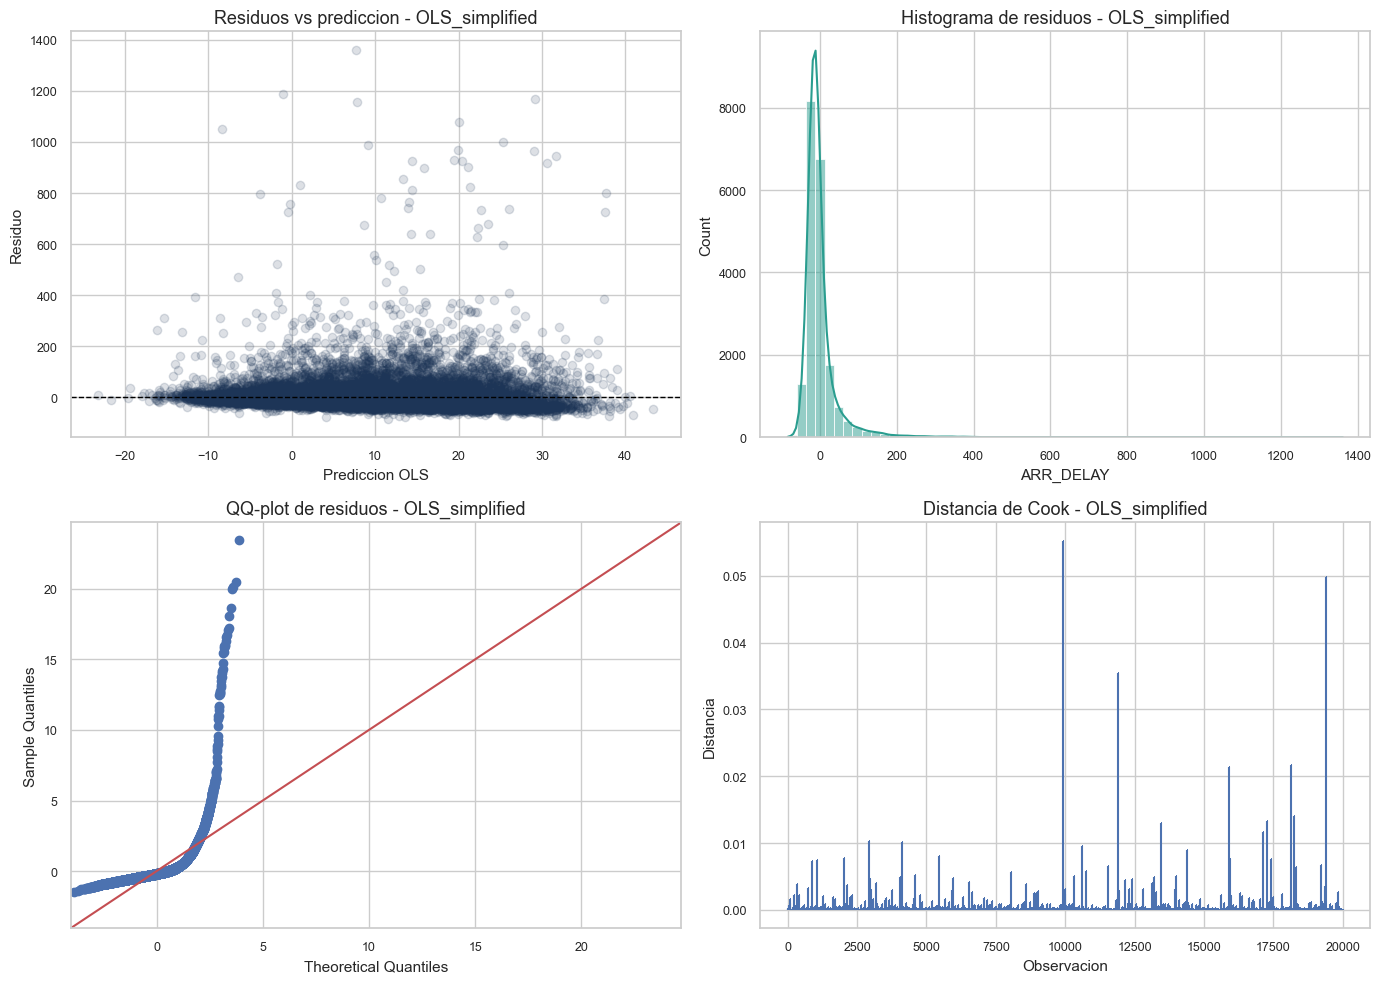

,feature,VIF
7,carrier_frequency,"5,643.194"
24,OP_UNIQUE_CARRIER_WN,"2,296.361"
15,OP_UNIQUE_CARRIER_DL,685.036
12,OP_UNIQUE_CARRIER_AA,588.323
23,OP_UNIQUE_CARRIER_UA,240.165
22,OP_UNIQUE_CARRIER_OO,177.817
5,DISTANCE_GROUP,131.846
4,DISTANCE,107.264
72,DEST_STATE_ABR_CA,24.954
111,DEST_STATE_ABR_TX,23.765


,diag_row_id,cooks_distance
9912,75575,0.055
19407,47833,0.050
11891,125634,0.035
18131,5975,0.022
15893,20158,0.021
18229,67009,0.014
17267,183752,0.013
13435,6645,0.013
17142,153745,0.012
2937,77803,0.010


,metric,value
0,diagnostic_rows,"20,000.000"
1,R2,0.026
2,R2_adj,0.025
3,F_statistic,44.416
4,F_pvalue,0.000
5,residual_mean,0.261
6,residual_std,58.044
7,share_large_cooks,0.024
8,max_vif,"5,643.194"


In [16]:
OLS_SELECTION_GAIN_TOL = 0.01
OLS_SELECTION_DRIFT_TOL = 0.02
OLS_SELECTION_ADJR2_TOL = 5e-4


def evaluate_ols_spec(model_label: str, selected_cols: list[str]) -> dict:
    X_train_selected = ols_X_train[selected_cols].copy()

    model = sm.OLS(y_train_ols, sm.add_constant(X_train_selected, has_constant="add")).fit()
    train_pred = model.predict(sm.add_constant(X_train_selected, has_constant="add"))
    valid_pred = predict_ols_in_chunks(
        model,
        valid_feat,
        ols_numeric_features,
        ols_categorical_features,
        ols_medians,
        ols_train_columns,
        selected_cols=selected_cols,
    )
    test_pred = predict_ols_in_chunks(
        model,
        test_feat,
        ols_numeric_features,
        ols_categorical_features,
        ols_medians,
        ols_train_columns,
        selected_cols=selected_cols,
    )

    metrics = {
        "model": model_label,
        "train_Adj_R2": model.rsquared_adj,
        "train_MAE": mean_absolute_error(y_train_ols, train_pred),
        "train_RMSE": np.sqrt(mean_squared_error(y_train_ols, train_pred)),
        "valid_MAE": mean_absolute_error(y_valid, valid_pred),
        "valid_RMSE": np.sqrt(mean_squared_error(y_valid, valid_pred)),
        "test_MAE": mean_absolute_error(y_test, test_pred),
        "test_RMSE": np.sqrt(mean_squared_error(y_test, test_pred)),
    }

    return {
        "model": model,
        "selected_cols": selected_cols,
        "X_train": X_train_selected,
        "train_pred": train_pred,
        "valid_pred": valid_pred,
        "test_pred": test_pred,
        "metrics": metrics,
    }


def is_defensible_improvement(
    trial_metrics: dict,
    current_metrics: dict,
    gain_tol: float = OLS_SELECTION_GAIN_TOL,
    drift_tol: float = OLS_SELECTION_DRIFT_TOL,
    adjr2_tol: float = OLS_SELECTION_ADJR2_TOL,
) -> bool:
    no_material_drift = (
        trial_metrics["valid_RMSE"] <= current_metrics["valid_RMSE"] + drift_tol
        and trial_metrics["valid_MAE"] <= current_metrics["valid_MAE"] + drift_tol
        and trial_metrics["test_RMSE"] <= current_metrics["test_RMSE"] + drift_tol
        and trial_metrics["test_MAE"] <= current_metrics["test_MAE"] + drift_tol
        and trial_metrics["train_Adj_R2"] >= current_metrics["train_Adj_R2"] - adjr2_tol
    )

    meaningful_gain = any(
        trial_metrics[metric] < current_metrics[metric] - gain_tol
        for metric in ["valid_RMSE", "valid_MAE", "test_RMSE", "test_MAE"]
    )

    return no_material_drift and meaningful_gain


full_result = {
    "model": ols_full,
    "selected_cols": ols_X_train.columns.tolist(),
    "X_train": ols_X_train,
    "train_pred": ols_full_train_pred,
    "valid_pred": ols_full_valid_pred,
    "test_pred": ols_full_test_pred,
    "metrics": {
        "model": "OLS_full",
        "train_Adj_R2": ols_full.rsquared_adj,
        "train_MAE": mean_absolute_error(y_train_ols, ols_full_train_pred),
        "train_RMSE": np.sqrt(mean_squared_error(y_train_ols, ols_full_train_pred)),
        "valid_MAE": mean_absolute_error(y_valid, ols_full_valid_pred),
        "valid_RMSE": np.sqrt(mean_squared_error(y_valid, ols_full_valid_pred)),
        "test_MAE": mean_absolute_error(y_test, ols_full_test_pred),
        "test_RMSE": np.sqrt(mean_squared_error(y_test, ols_full_test_pred)),
    },
}

full_diagnostics = build_ols_diagnostics(ols_full, ols_X_train, y_train_ols, ols_full_train_pred)

high_p_features = set(
    coef_table_full.loc[
        (coef_table_full["feature"] != "const") & (coef_table_full["p_value"] > 0.10),
        "feature",
    ]
)
high_vif_features = set(full_diagnostics["vif_df"].loc[full_diagnostics["vif_df"]["VIF"] > 10, "feature"])

origin_state_candidates = sorted(
    feature
    for feature in (high_p_features & high_vif_features)
    if feature.startswith("ORIGIN_STATE_ABR_")
)
dest_state_candidates = sorted(
    feature
    for feature in (high_p_features & high_vif_features)
    if feature.startswith("DEST_STATE_ABR_")
)

candidate_pool = []

if "origin_frequency" in high_p_features:
    candidate_pool.append(
        {
            "label": "minus_origin_frequency",
            "features": ["origin_frequency"],
            "reason": "Tiene p-value alto y puede solaparse con otras proxies historicas de actividad.",
        }
    )

if "DISTANCE" in high_p_features and "DISTANCE_GROUP" in ols_X_train.columns:
    candidate_pool.append(
        {
            "label": "minus_DISTANCE",
            "features": ["DISTANCE"],
            "reason": "DISTANCE aporta poca evidencia estadistica y puede ser redundante con DISTANCE_GROUP.",
        }
    )
elif "DISTANCE_GROUP" in high_p_features and "DISTANCE" in ols_X_train.columns:
    candidate_pool.append(
        {
            "label": "minus_DISTANCE_GROUP",
            "features": ["DISTANCE_GROUP"],
            "reason": "DISTANCE_GROUP aporta poca evidencia estadistica y puede ser redundante con DISTANCE.",
        }
    )

if dest_state_candidates:
    candidate_pool.append(
        {
            "label": "minus_dest_state_dummies",
            "features": dest_state_candidates,
            "reason": "Bloque pequeno de dummies de estado destino con p-value alto y VIF elevado en la submuestra diagnostica.",
        }
    )

if origin_state_candidates:
    candidate_pool.append(
        {
            "label": "minus_origin_state_dummies",
            "features": origin_state_candidates,
            "reason": "Bloque pequeno de dummies de estado origen con p-value alto y VIF elevado en la submuestra diagnostica.",
        }
    )

if "origin_frequency" in high_p_features and dest_state_candidates:
    candidate_pool.append(
        {
            "label": "minus_origin_frequency_and_dest_state_dummies",
            "features": ["origin_frequency", *dest_state_candidates],
            "reason": "Prueba conjunta ligera para comprobar si la limpieza de proxies y dummies debiles mejora la generalizacion.",
        }
    )

candidate_review_df = pd.DataFrame(
    [
        {
            "candidate": item["label"],
            "n_features": len(item["features"]),
            "features_preview": ", ".join(item["features"][:4]) + ("..." if len(item["features"]) > 4 else ""),
            "reason": item["reason"],
        }
        for item in candidate_pool
    ]
)

display(
    candidate_review_df
    if not candidate_review_df.empty
    else pd.DataFrame({"note": ["No se detectaron candidatos claros para una simplificacion adicional defendible."]})
)

selection_steps = []
accepted_drop_rows = []
best_result = full_result

for candidate in candidate_pool:
    candidate_features = [feature for feature in candidate["features"] if feature in best_result["selected_cols"]]
    if not candidate_features:
        continue

    trial_selected_cols = [col for col in best_result["selected_cols"] if col not in candidate_features]
    trial_result = evaluate_ols_spec("OLS_simplified", trial_selected_cols)
    accepted = is_defensible_improvement(trial_result["metrics"], best_result["metrics"])

    decision_note = (
        "Se acepta: mejora al menos una metrica fuera de train sin deterioro material en las demas."
        if accepted
        else "Se rechaza: no mejora valid/test de forma defendible o el beneficio es irrelevante."
    )

    selection_steps.append(
        {
            "candidate": candidate["label"],
            "accepted": accepted,
            "n_removed": len(candidate_features),
            "removed_features": ", ".join(candidate_features[:6]) + ("..." if len(candidate_features) > 6 else ""),
            "train_Adj_R2": trial_result["metrics"]["train_Adj_R2"],
            "valid_MAE": trial_result["metrics"]["valid_MAE"],
            "valid_RMSE": trial_result["metrics"]["valid_RMSE"],
            "test_MAE": trial_result["metrics"]["test_MAE"],
            "test_RMSE": trial_result["metrics"]["test_RMSE"],
            "decision_note": decision_note,
        }
    )

    if accepted:
        best_result = trial_result
        accepted_drop_rows.extend(
            {"feature": feature, "reason": candidate["reason"]}
            for feature in candidate_features
        )

ols_selection_history_df = pd.DataFrame(selection_steps)
display(
    ols_selection_history_df
    if not ols_selection_history_df.empty
    else pd.DataFrame({"note": ["No hubo pasos adicionales de seleccion porque no aparecieron candidatos solidos."]})
)

ols_removed_features_df = pd.DataFrame(accepted_drop_rows).drop_duplicates(subset=["feature"]).reset_index(drop=True)
display(
    ols_removed_features_df
    if not ols_removed_features_df.empty
    else pd.DataFrame({"note": ["Se conserva el OLS actual: ninguna eliminacion adicional mejoro valid/test de forma clara."]})
)

simplified_cols = best_result["selected_cols"]
ols_X_train_simple = best_result["X_train"].copy()
ols_simple = best_result["model"]
ols_simple_train_pred = best_result["train_pred"]
ols_simple_valid_pred = best_result["valid_pred"]
ols_simple_test_pred = best_result["test_pred"]
ols_residuals = y_train_ols - ols_simple_train_pred

print(ols_simple.summary())

register_results("OLS_simplified", "train", y_train_ols, ols_simple_train_pred)
register_results("OLS_simplified", "valid", y_valid, ols_simple_valid_pred)
register_results("OLS_simplified", "test", y_test, ols_simple_test_pred)

ols_train_adj_r2_map = {
    "OLS_full": full_result["metrics"]["train_Adj_R2"],
    "OLS_simplified": best_result["metrics"]["train_Adj_R2"],
}

ols_compare_head_to_head = pd.DataFrame(
    [
        full_result["metrics"],
        {**best_result["metrics"], "model": "OLS_simplified"},
    ]
)[[
    "model",
    "train_Adj_R2",
    "train_MAE",
    "train_RMSE",
    "valid_MAE",
    "valid_RMSE",
    "test_MAE",
    "test_RMSE",
]]

display(ols_compare_head_to_head)

ols_final_label = "OLS_simplified" if not ols_removed_features_df.empty else "OLS_full_conservado"
print(f"OLS final recomendado: {ols_final_label}")

final_diagnostics = build_ols_diagnostics(ols_simple, ols_X_train_simple, y_train_ols, ols_simple_train_pred)
display_ols_diagnostics(final_diagnostics, ols_final_label)


### Conclusión del modelo lineal

La simplificación adicional del modelo OLS produce una mejora muy pequeña, pero consistente, fuera de entrenamiento. En concreto, el modelo simplificado mantiene un `Adjusted R²` muy parecido en train y mejora ligeramente `MAE` y `RMSE` tanto en `valid_2023` como en `test_2024`. Por ello, no se interpreta como un salto de rendimiento, sino como una mejora de parsimonia y limpieza del modelo.

La poda final elimina únicamente algunos niveles de `ORIGIN_STATE_ABR` cuya contribución era dudosa y cuya retirada no perjudica la generalización. En esta formulación, dichos niveles quedan absorbidos por la categoría de referencia, por lo que el efecto del estado de origen no desaparece del modelo, sino que se representa de forma más compacta. En consecuencia, para la parte lineal del trabajo se considera preferible defender `OLS_simplified`, ya que reduce ruido interpretativo sin coste material en capacidad predictiva.


## 10. Modelo no lineal de comparacion: Random Forest Regressor

La regresion lineal es util para interpretar, pero puede quedarse corta si existen:
- relaciones no lineales,
- interacciones entre origen, destino, franja y aerolinea,
- colas largas en la variable objetivo.

La comparacion con `RandomForestRegressor` se hace con solo dos configuraciones razonables y usando la misma submuestra reproducible de `train_2023`. La seleccion se hace por `RMSE` en `valid_2023`, sin validacion cruzada pesada y sin tocar `test_2024` hasta el final.


In [17]:

rf_train = rf_train_feat.copy()

X_train_rf = rf_train[tree_numeric_features + tree_categorical_features].copy()
y_train_rf = rf_train[TARGET_COL].copy()

X_valid_rf = valid_feat[tree_numeric_features + tree_categorical_features].copy()
X_test_rf = test_feat[tree_numeric_features + tree_categorical_features].copy()

rf_configurations = [
    {
        "label": "RF_depth12_leaf10",
        "n_estimators": 80,
        "max_depth": 12,
        "min_samples_leaf": 10,
        "max_features": "sqrt",
        "random_state": RANDOM_STATE,
        "n_jobs": 1,
    },
    {
        "label": "RF_depth10_leaf20",
        "n_estimators": 120,
        "max_depth": 10,
        "min_samples_leaf": 20,
        "max_features": "sqrt",
        "random_state": RANDOM_STATE,
        "n_jobs": 1,
    },
]

rf_candidates = {}
rf_valid_selection = []

for config in rf_configurations:
    config = config.copy()
    label = config.pop("label")

    candidate_pipeline = Pipeline(
        steps=[
            ("preprocess", tree_preprocessor),
            ("model", RandomForestRegressor(**config)),
        ]
    )

    candidate_pipeline.fit(X_train_rf, y_train_rf)
    valid_pred = predict_sklearn_in_chunks(candidate_pipeline, X_valid_rf)
    valid_metrics = regression_metrics(y_valid, valid_pred, label, "valid")

    rf_valid_selection.append(
        {
            "config": label,
            **config,
            "valid_MAE": valid_metrics["MAE"],
            "valid_RMSE": valid_metrics["RMSE"],
            "valid_R2": valid_metrics["R2"],
        }
    )
    rf_candidates[label] = {"pipeline": candidate_pipeline, "valid_pred": valid_pred, "params": config}

rf_valid_selection_df = pd.DataFrame(rf_valid_selection).sort_values("valid_RMSE").reset_index(drop=True)
display(rf_valid_selection_df)

best_rf_label = rf_valid_selection_df.loc[0, "config"]
best_rf = rf_candidates[best_rf_label]["pipeline"]
rf_valid_pred = rf_candidates[best_rf_label]["valid_pred"]

print(f"Configuracion seleccionada para RandomForest por RMSE en valid_2023: {best_rf_label}")

rf_train_pred = predict_sklearn_in_chunks(best_rf, X_train_rf)
rf_test_pred = predict_sklearn_in_chunks(best_rf, X_test_rf)

register_results("RandomForest", "train", y_train_rf, rf_train_pred)
register_results("RandomForest", "valid", y_valid, rf_valid_pred)
register_results("RandomForest", "test", y_test, rf_test_pred)

rf_feature_names = best_rf.named_steps["preprocess"].get_feature_names_out()
rf_importances = (
    pd.DataFrame(
        {
            "feature": rf_feature_names,
            "importance": best_rf.named_steps["model"].feature_importances_,
        }
    )
    .sort_values("importance", ascending=False)
    .head(20)
    .reset_index(drop=True)
)

display(pd.DataFrame(model_results).query("model == 'RandomForest'"))
display(rf_importances)


,config,n_estimators,max_depth,min_samples_leaf,max_features,random_state,n_jobs,valid_MAE,valid_RMSE,valid_R2
0,RF_depth12_leaf10,80,12,10,sqrt,42,1,24.353,47.098,-0.029
1,RF_depth10_leaf20,120,10,20,sqrt,42,1,24.461,47.106,-0.030


Configuracion seleccionada para RandomForest por RMSE en valid_2023: RF_depth12_leaf10


,model,split,MAE,MSE,RMSE,R2
9,RandomForest,train,26.435,"3,266.927",57.157,0.058
10,RandomForest,valid,24.353,"2,218.258",47.098,-0.029
11,RandomForest,test,27.270,"3,307.431",57.510,0.017


,feature,importance
0,num__crs_dep_hour,0.103
1,cat__dep_period_manana,0.053
2,num__DISTANCE,0.051
3,num__MONTH,0.049
4,num__route_frequency,0.045
5,num__origin_hour_frequency,0.042
6,num__origin_frequency,0.039
7,num__crs_dep_minute,0.039
8,num__DAY_OF_MONTH,0.037
9,num__dest_frequency,0.029



## 11. Evaluacion final y comparacion de modelos

La comparacion final resume tres cosas:
- rendimiento absoluto en `train`, `valid` y `test`,
- mejora real frente al baseline,
- y posible sobreajuste al pasar de `train` a datos fuera de muestra.


,model,split,MAE,MSE,RMSE,R2
0,RandomForest,test,27.270,"3,307.431",57.510,0.017
1,OLS_simplified,test,27.703,"3,326.628",57.677,0.011
2,OLS_full,test,27.723,"3,327.364",57.683,0.011
3,Baseline_mean,test,28.115,"3,366.049",58.018,-0.001
4,RandomForest,train,26.435,"3,266.927",57.157,0.058
5,OLS_full,train,27.094,"3,399.402",58.304,0.026
6,OLS_simplified,train,27.103,"3,401.186",58.320,0.026
7,Baseline_mean,train,28.098,"3,617.893",60.149,0.000
8,RandomForest,valid,24.353,"2,218.258",47.098,-0.029
9,Baseline_mean,valid,24.669,"2,230.574",47.229,-0.035


,train_Adj_R2,train_MAE,train_RMSE,train_R2,valid_MAE,valid_RMSE,valid_R2,test_MAE,test_RMSE,test_R2
model,,,,,,,,,,
RandomForest,NaN,26.435,57.157,0.058,24.353,47.098,-0.029,27.270,57.510,0.017
Baseline_mean,NaN,28.098,60.149,0.000,24.669,47.229,-0.035,28.115,58.018,-0.001
OLS_simplified,0.025,27.103,58.320,0.026,25.522,47.577,-0.050,27.703,57.677,0.011
OLS_full,0.026,27.094,58.304,0.026,25.550,47.584,-0.051,27.723,57.683,0.011


,model,valid_delta_MAE_vs_baseline,valid_delta_RMSE_vs_baseline,valid_pct_mejora_RMSE,test_delta_MAE_vs_baseline,test_delta_RMSE_vs_baseline,test_pct_mejora_RMSE
0,RandomForest,-0.316,-0.131,0.276,-0.845,-0.507,0.875
1,OLS_simplified,0.853,0.348,-0.737,-0.412,-0.341,0.587
2,OLS_full,0.881,0.355,-0.752,-0.392,-0.334,0.576


Modelo seleccionado con criterio de validacion temporal (RMSE): RandomForest


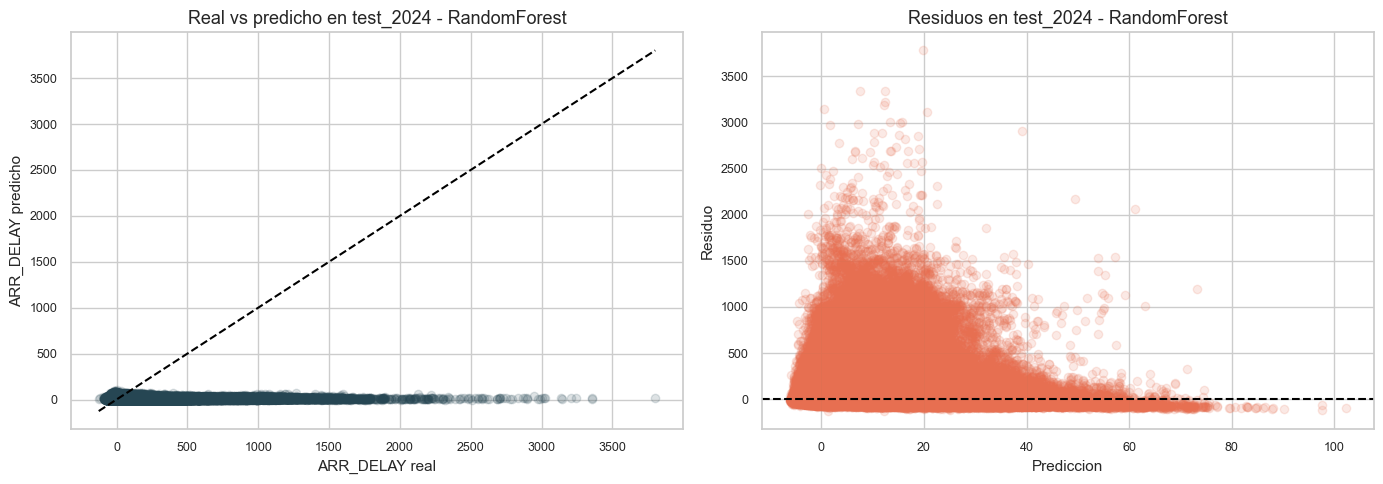

split,test,train,valid,train_valid_gap,train_test_gap
model,,,,,
RandomForest,57.510,57.157,47.098,-10.059,0.353
OLS_simplified,57.677,58.320,47.577,-10.743,-0.643
OLS_full,57.683,58.304,47.584,-10.720,-0.621


In [18]:
results_df = (
    pd.DataFrame(model_results)
    .drop_duplicates(subset=["model", "split"], keep="last")
    .sort_values(["split", "RMSE", "MAE"])
    .reset_index(drop=True)
)
display(results_df)

final_metrics_table = (
    results_df.pivot(index="model", columns="split", values=["MAE", "RMSE", "R2"])
    .sort_index(axis=1)
)
final_metrics_table.columns = [f"{split}_{metric}" for metric, split in final_metrics_table.columns]
final_metrics_table["train_Adj_R2"] = final_metrics_table.index.to_series().map(globals().get("ols_train_adj_r2_map", {}))
ordered_cols = [
    "train_Adj_R2",
    "train_MAE", "train_RMSE", "train_R2",
    "valid_MAE", "valid_RMSE", "valid_R2",
    "test_MAE", "test_RMSE", "test_R2",
]
final_metrics_table = final_metrics_table[ordered_cols].sort_values("valid_RMSE")
display(final_metrics_table)

baseline_reference = (
    results_df.query("model == 'Baseline_mean'")[["split", "MAE", "RMSE"]]
    .set_index("split")
)

improvement_rows = []
for model_name in final_metrics_table.index:
    if model_name == "Baseline_mean":
        continue

    valid_row = results_df.query("model == @model_name and split == 'valid'").iloc[0]
    test_row = results_df.query("model == @model_name and split == 'test'").iloc[0]

    valid_delta_rmse = valid_row["RMSE"] - baseline_reference.loc["valid", "RMSE"]
    test_delta_rmse = test_row["RMSE"] - baseline_reference.loc["test", "RMSE"]

    improvement_rows.append(
        {
            "model": model_name,
            "valid_delta_MAE_vs_baseline": valid_row["MAE"] - baseline_reference.loc["valid", "MAE"],
            "valid_delta_RMSE_vs_baseline": valid_delta_rmse,
            "valid_pct_mejora_RMSE": 100 * (-valid_delta_rmse) / baseline_reference.loc["valid", "RMSE"],
            "test_delta_MAE_vs_baseline": test_row["MAE"] - baseline_reference.loc["test", "MAE"],
            "test_delta_RMSE_vs_baseline": test_delta_rmse,
            "test_pct_mejora_RMSE": 100 * (-test_delta_rmse) / baseline_reference.loc["test", "RMSE"],
        }
    )

improvement_vs_baseline = pd.DataFrame(improvement_rows).sort_values("valid_delta_RMSE_vs_baseline")
display(improvement_vs_baseline)

valid_ranking = results_df.query("split == 'valid'").sort_values("RMSE").reset_index(drop=True)
selected_model = valid_ranking.iloc[0]["model"]

print(f"Modelo seleccionado con criterio de validacion temporal (RMSE): {selected_model}")

selected_test_pred = model_predictions[selected_model]["test"]["y_pred"]
selected_test_true = model_predictions[selected_model]["test"]["y_true"]
selected_test_residuals = selected_test_true - selected_test_pred

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(selected_test_true, selected_test_pred, alpha=0.15, color="#264653")
limits = [
    min(selected_test_true.min(), selected_test_pred.min()),
    max(selected_test_true.max(), selected_test_pred.max()),
]
axes[0].plot(limits, limits, linestyle="--", color="black")
axes[0].set_title(f"Real vs predicho en test_2024 - {selected_model}")
axes[0].set_xlabel("ARR_DELAY real")
axes[0].set_ylabel("ARR_DELAY predicho")

axes[1].scatter(selected_test_pred, selected_test_residuals, alpha=0.15, color="#e76f51")
axes[1].axhline(0, linestyle="--", color="black")
axes[1].set_title(f"Residuos en test_2024 - {selected_model}")
axes[1].set_xlabel("Prediccion")
axes[1].set_ylabel("Residuo")

plt.tight_layout()
plt.show()

overfit_table = (
    results_df.query("model != 'Baseline_mean'")
    .pivot(index="model", columns="split", values="RMSE")
    .assign(
        train_valid_gap=lambda df_: df_["valid"] - df_["train"],
        train_test_gap=lambda df_: df_["test"] - df_["train"],
    )
    .sort_values("test")
)

display(overfit_table)



## 12. Discusion final

### 1. Resultados predictivos

La comparación final muestra que la capacidad predictiva de la regresión es limitada, pero no arbitraria. El modelo que obtiene el menor error es `RandomForest`, mientras que `OLS_full` y `OLS_simplified` quedan muy cerca entre sí y mejoran solo de forma modesta respecto al baseline. Esta lectura debe hacerse sobre todo con `MAE` y `RMSE`, ya que en un problema como `ARR_DELAY` la presencia de alta variabilidad no observada y de retrasos extremos hace que el `R²` sea difícil de interpretar por sí solo.

Por tanto, la conclusión correcta no es que el ejercicio haya fallado, sino que predecir la magnitud exacta del retraso antes del despegue es un problema intrínsecamente más difícil que estimar una etiqueta binaria de retraso relevante. La mejora frente al baseline existe, pero es pequeña, lo que indica que con las variables disponibles se capturan patrones estructurales, aunque no se consigue explicar con precisión fina la variabilidad minuto a minuto.

### 2. Interpretacion de variables y lectura metodologica

Desde el punto de vista metodológico, el notebook sigue una lógica coherente con la regresión trabajada en clase: se parte de un modelo lineal amplio, se revisan significación, residuos, Cook’s distance y VIF, y después se simplifica el OLS buscando un equilibrio entre ajuste, estabilidad e interpretabilidad. La versión simplificada del modelo lineal no aporta una mejora grande en error, pero sí una ligera ganancia de generalización y una estructura más limpia, por lo que resulta más defendible como modelo interpretable.

Las variables con mayor señal sugieren que parte del retraso está asociada a patrones operativos estructurales, especialmente la hora programada de salida, la aerolínea, determinadas rutas y proxies históricas como la frecuencia de ruta o de aeropuerto-franja. Esta lectura tiene sentido desde el dominio del problema: los retrasos no dependen solo de una causa puntual, sino de acumulaciones de congestión, diferencias operativas entre rutas y franjas horarias y características recurrentes de la red aérea.

### 3. Regresion dentro del proyecto

La regresión no sustituye al objetivo principal del proyecto, que sigue siendo la clasificación del retraso relevante, pero sí aporta valor como extensión metodológica y explicativa. Permite evaluar hasta qué punto la información disponible antes del despegue basta para estimar una magnitud continua y no solo una categoría binaria. El resultado obtenido sugiere que esa información permite aproximaciones gruesas, pero no predicciones precisas de minutos exactos.

En este sentido, la parte de regresión refuerza una conclusión importante del proyecto: con variables predespegue, la formulación en clasificación parece más robusta y más útil como objetivo principal, mientras que la regresión queda mejor justificada como herramienta complementaria para interpretar patrones medios y para mostrar los límites reales del problema predictivo.
